# Εργασία 2

Load Data

In [168]:
import pandas as pd

#Load CSV file
csv_file = 'data.csv'
data = pd.read_csv(csv_file)
total_count = len(data)

Data split

In [169]:
from sklearn.model_selection import train_test_split


# Data separation by class
class_0 = data[data['class'] == 0]
class_1 = data[data['class'] == 1]

# 1st train_split for each class 
# 60% train 40% temporary
X_train_0, X_temp_0, y_train_0, y_temp_0 = train_test_split(class_0.drop(columns=['class']), class_0['class'], test_size=0.4, random_state=42, stratify=class_0['class']) 
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(class_1.drop(columns=['class']), class_1['class'], test_size=0.4, random_state=42, stratify=class_1['class'])


# train data combination from each class
X_train = pd.concat([X_train_0, X_train_1]).sample(frac=1, random_state=42)
y_train = pd.concat([y_train_0, y_train_1]).sample(frac=1, random_state=42)

# temporary data combination from each class
X_temp = pd.concat([X_temp_0, X_temp_1]).sample(frac=1, random_state=42)
y_temp = pd.concat([y_temp_0, y_temp_1]).sample(frac=1, random_state=42)

# 2nd train_split for validation and train data 
# 50% validation  50% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42,stratify=y_temp)

# Combination features and tags 
train_data = pd.concat([X_train, y_train], axis=1) 
val_data = pd.concat([X_val, y_val], axis=1)        
test_data = pd.concat([X_test, y_test], axis=1)     

train_data.to_csv("train_data.csv", index=False)
val_data.to_csv("val_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)


# Ερώτημα 1

PCA method

Explained Variance Ratio: [0.55124209 0.31938523]


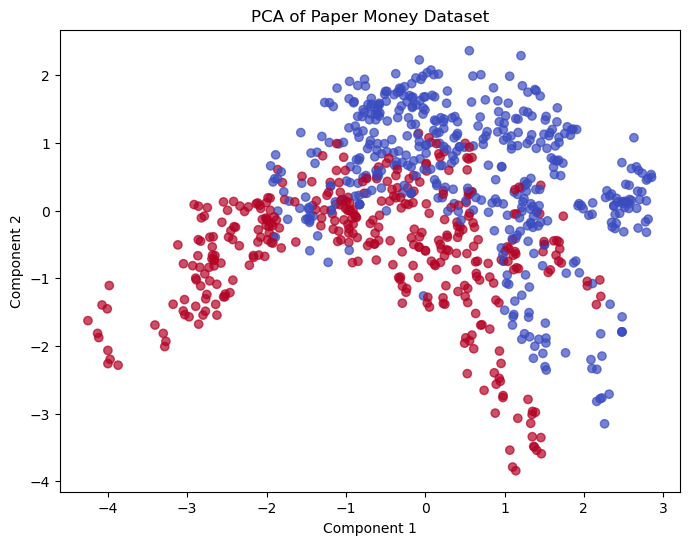

In [170]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Data normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA to reduce features in 2 dimensions
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Explained Variance Ratio:", pca.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,cmap="coolwarm",alpha=0.7) 
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PCA of Paper Money Dataset")
plt.show()

Parzen Windows classification

   Bandwidth  F1 Score
0       0.05  0.846082
1       0.10  0.864489
2       0.20  0.853220
3       0.30  0.802557
4       0.50  0.772788
5       0.75  0.779516
6       1.00  0.753058
7       1.50  0.731638
8       2.00  0.704874
9       3.00  0.610140


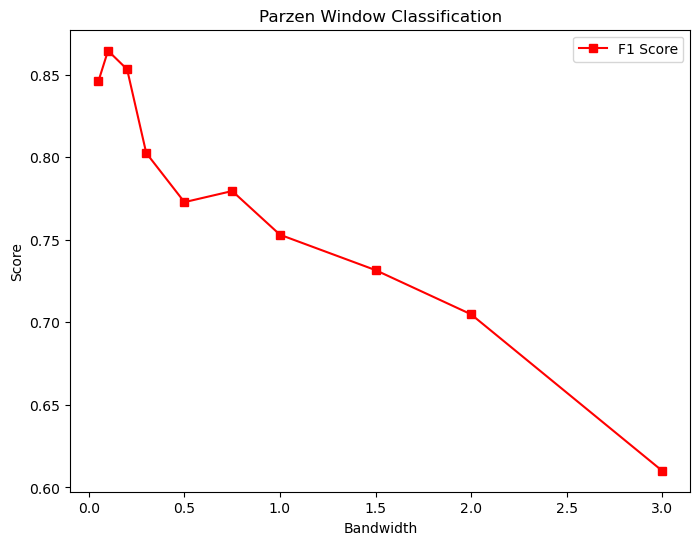

In [171]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Gaussian kernel function
def gaussian_kernel(distances, h):
    """Calculate the Gaussian kernel values for given distances."""
    return np.exp(-0.5 * (distances / h) ** 2) / (np.sqrt(2 * np.pi) * h)

# Parzen Window Classifier
def parzen_window_classifier(data, labels, query_point, h):
    """Classify a query point using Parzen Windows with Gaussian Kernel."""
    unique_classes = np.unique(labels)
    densities = {}
    
    for c in unique_classes:
        class_data = data[labels == c]  
        distances = np.linalg.norm(query_point - class_data, axis=1)  
        densities[c] = np.sum(gaussian_kernel(distances, h)) 
    
    # Return class with highest density
    return max(densities, key=densities.get)  

# Bandwidth for Parzen Windows
bandwidths = [0.05,0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0] 
results = []

y_pred_all = {}
for h in bandwidths:
    y_pred = [parzen_window_classifier(X_train_pca, y_train, query_point, h) for query_point in X_val_pca]
    
    
    f1 = f1_score(y_val, y_pred, average='weighted')
    results.append((h, f1))
    y_pred_all[h] = y_pred 


results_df = pd.DataFrame(results, columns=['Bandwidth','F1 Score'])
print(results_df)

plt.figure(figsize=(8, 6))
plt.plot(results_df['Bandwidth'], results_df['F1 Score'], marker='s', linestyle='-', color='r', label='F1 Score')
plt.xlabel("Bandwidth")
plt.ylabel("Score")
plt.title("Parzen Window Classification")
plt.legend()
plt.show()

# Ερώτημα 2

k-NN classification

      k  F1 Score
0     1  0.850302
1     3  0.846267
2     5  0.861059
3     7  0.835377
4     9  0.838753
5    11  0.815981
6    15  0.812448
7    20  0.800932
8    25  0.805890
9    30  0.801260
10   50  0.783028
11   80  0.776004
12  100  0.776590


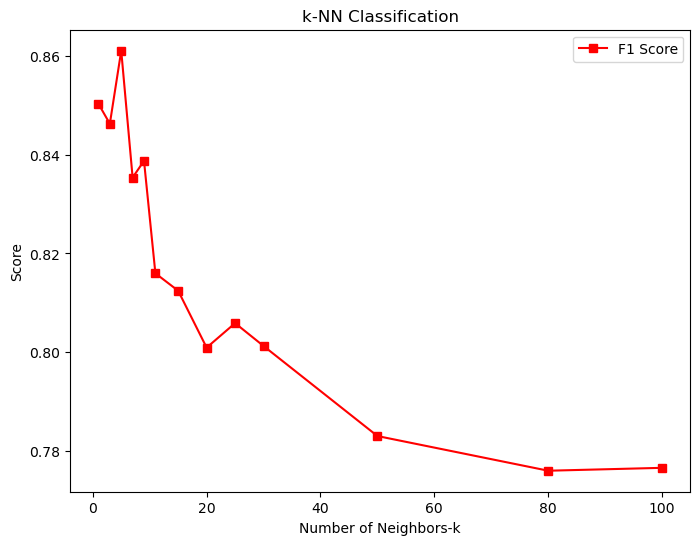

In [172]:
from sklearn.neighbors import KNeighborsClassifier

# k-NN 
k_val= [1, 3, 5, 7, 9, 11, 15, 20, 25, 30, 50, 80, 100]
k_results = []

for k in k_val:
    # k-NN training
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train)
    
    # Prediction for validation data
    y_pred = knn.predict(X_val_pca)
    
    
    
    f1 = f1_score(y_val, y_pred, average='weighted')
    k_results.append((k, f1))


k_results_df = pd.DataFrame(k_results, columns=['k','F1 Score'])
print(k_results_df)


plt.figure(figsize=(8, 6))
plt.plot(k_results_df['k'], k_results_df['F1 Score'], marker='s', linestyle='-', color='r', label="F1 Score")

plt.xlabel("Number of Neighbors-k")
plt.ylabel("Score")
plt.title("k-NN Classification")
plt.legend()
plt.show()


# Ερώτημα 3

SVM classification

    Kernel       C  F1 Score
0   linear    0.01  0.725658
1   linear    0.05  0.715897
2   linear    0.10  0.715897
3   linear    0.50  0.719335
4   linear    1.00  0.715897
5   linear    5.00  0.715897
6   linear   10.00  0.715897
7   linear   20.00  0.715897
8   linear   50.00  0.715897
9   linear  100.00  0.715897
10  linear  200.00  0.715897
11     rbf    0.01  0.691813
12     rbf    0.05  0.773060
13     rbf    0.10  0.765152
14     rbf    0.50  0.772491
15     rbf    1.00  0.793899
16     rbf    5.00  0.792804
17     rbf   10.00  0.793194
18     rbf   20.00  0.792804
19     rbf   50.00  0.799804
20     rbf  100.00  0.799804
21     rbf  200.00  0.796699


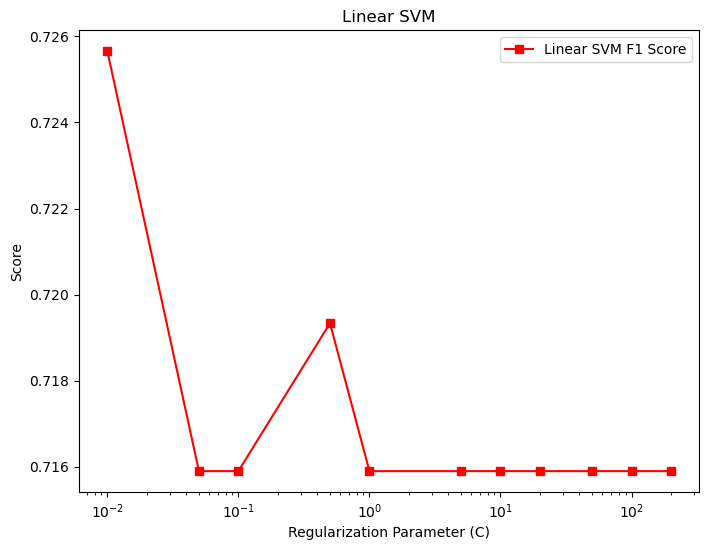

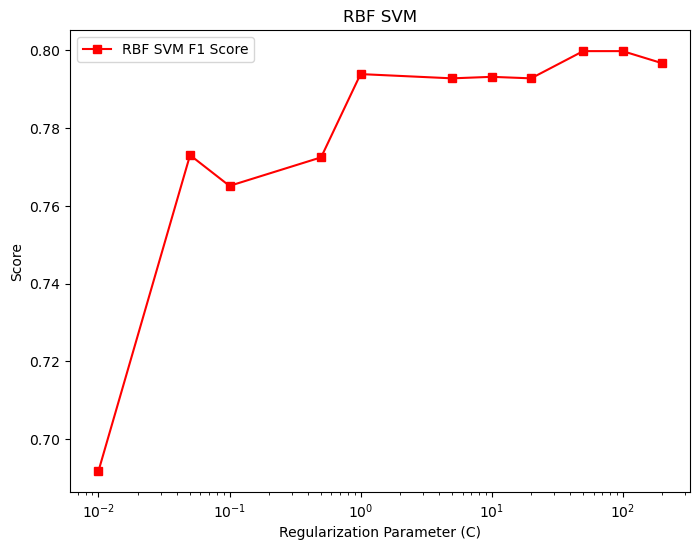

In [173]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.svm import SVC


# SVM Classification (Linear and Non-Linear)
c_val =  [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 20, 50, 100, 200] 
kernels = ['linear', 'rbf']
svm_results = []


for kernel in kernels:
    for c in c_val:
        svm = SVC(kernel=kernel, C=c)
        svm.fit(X_train_pca, y_train)
        y_pred = svm.predict(X_val_pca)
       
        
        f1 = f1_score(y_val, y_pred, average='weighted')
        svm_results.append((kernel, c, f1))
        
    

svm_results_df = pd.DataFrame(svm_results, columns=['Kernel', 'C', 'F1 Score'])
print(svm_results_df)


# Separation in the 2 models
linear_df = svm_results_df[svm_results_df['Kernel'] == 'linear']
rbf_df = svm_results_df[svm_results_df['Kernel'] == 'rbf']

# Linear SVM
plt.figure(figsize=(8, 6))

plt.plot(linear_df['C'], linear_df['F1 Score'], marker='s', linestyle='-', color='r', label="Linear SVM F1 Score")

plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Score")
plt.title("Linear SVM")
plt.xscale('log')  # Logarithmic scale for C
plt.legend()
plt.show()

# RBF SVM
plt.figure(figsize=(8, 6))

plt.plot(rbf_df['C'], rbf_df['F1 Score'], marker='s', linestyle='-', color='r', label="RBF SVM F1 Score")

plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Score")
plt.title("RBF SVM")
plt.xscale('log')  
plt.legend()
plt.show()
